# Acceptance-Rejection Sampling Tutorial

This notebook reproduces the steps from the article about Acceptance-Rejection Sampling method, which is a fundamental technique for generating samples from probability distributions.

## 1. Introduction to Acceptance-Rejection Sampling

Acceptance-Rejection Sampling is a Monte Carlo method used to generate observations from a probability distribution. The basic idea is to:
1. Find a proposal distribution that is easy to sample from
2. Scale it to envelope the target distribution
3. Sample from the proposal distribution
4. Accept or reject samples based on a probability criterion

In [1]:
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Define Target Distribution

Let's define a target probability density function that we want to sample from. For this example, we'll use a custom distribution.

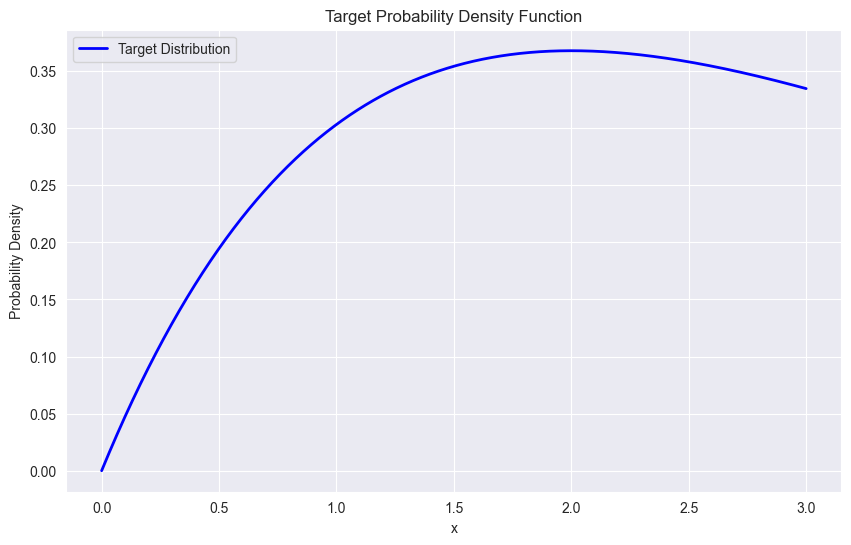

In [2]:
# Define the target probability density function
def target_pdf(x):
    """Example target distribution"""
    if 0 <= x <= 3:
        return (x * math.exp(-x/2)) / 2  # Custom distribution
    else:
        return 0

# Plot the target distribution
x_values = np.linspace(0, 3, 1000)
y_values = [target_pdf(x) for x in x_values]

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution')
plt.title('Target Probability Density Function')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## 3. Define Proposal Distribution

Now we need to define a proposal distribution that is easy to sample from and can envelope our target distribution when scaled. We'll use a uniform distribution as the proposal distribution.

Maximum value of target PDF: 0.3679
Scaling factor c: 1.1036


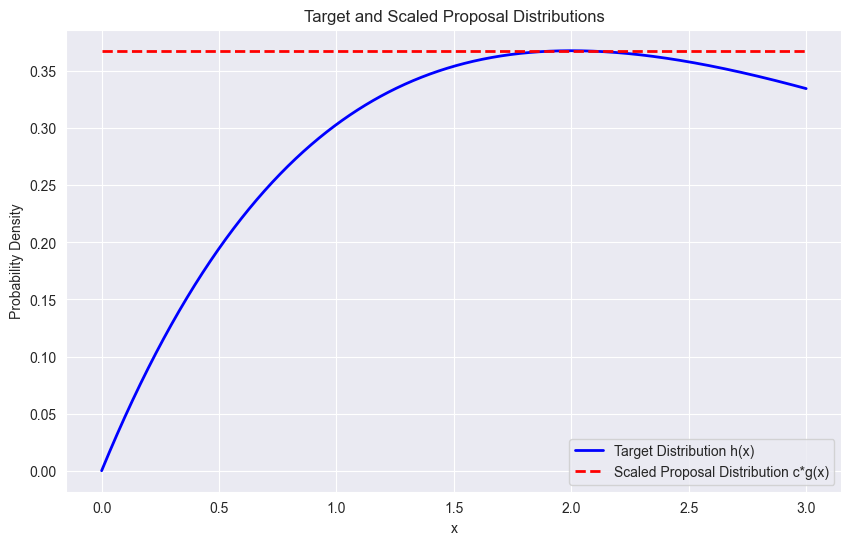

In [3]:
# Find the maximum value of the target PDF to determine the scaling factor
max_y = max(y_values)
print(f"Maximum value of target PDF: {max_y:.4f}")

# Define the proposal distribution (uniform in this case)
def proposal_pdf(x):
    """Uniform proposal distribution"""
    if 0 <= x <= 3:
        return 1/3  # Uniform distribution on [0, 3]
    else:
        return 0

# Calculate the scaling factor c
c = max_y * 3  # c = max(h(x)/g(x)) where g(x) is uniform
print(f"Scaling factor c: {c:.4f}")

# Plot both distributions
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution h(x)')
plt.plot(x_values, [c * proposal_pdf(x) for x in x_values], 'r--', linewidth=2, label=f'Scaled Proposal Distribution c*g(x)')
plt.title('Target and Scaled Proposal Distributions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## 4. Implement Acceptance-Rejection Sampling Algorithm

Now we'll implement the core algorithm that generates samples from our target distribution using the proposal distribution.

In [4]:
def acceptance_rejection_sampling(num_samples):
    """Generate samples from target distribution using acceptance-rejection method"""
    samples = []
    rejected_points = []
    accepted_points = []
    
    while len(samples) < num_samples:
        # Step 1: Sample from proposal distribution (uniform in this case)
        x_star = random.uniform(0, 3)
        
        # Step 2: Sample y from uniform distribution between 0 and c*g(x_star)
        y = random.uniform(0, c * proposal_pdf(x_star))
        
        # Step 3: Accept or reject
        if y <= target_pdf(x_star):
            samples.append(x_star)
            accepted_points.append((x_star, y))
        else:
            rejected_points.append((x_star, y))
    
    return samples, accepted_points, rejected_points

# Generate samples
num_samples = 100000
samples, accepted_points, rejected_points = acceptance_rejection_sampling(num_samples)

print(f"Generated {len(samples)} samples from the target distribution")
print(f"Total points generated: {len(accepted_points) + len(rejected_points)}")
print(f"Acceptance rate: {len(accepted_points) / (len(accepted_points) + len(rejected_points)):.2%}")

Generated 100000 samples from the target distribution
Total points generated: 125024
Acceptance rate: 79.98%


## 5. Visualize the Sampling Process

Let's visualize the sampling process to see how points are accepted or rejected.

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


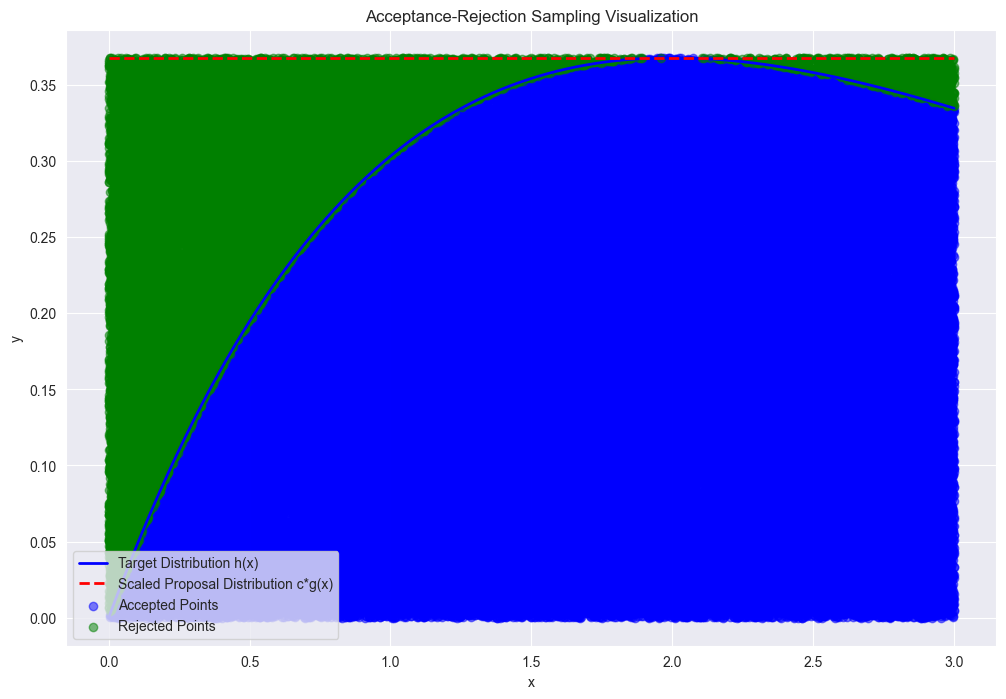

In [5]:
# Visualize the sampling process
plt.figure(figsize=(12, 8))

# Plot the target distribution
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution h(x)')
plt.plot(x_values, [c * proposal_pdf(x) for x in x_values], 'r--', linewidth=2, label=f'Scaled Proposal Distribution c*g(x)')

# Plot accepted and rejected points
if accepted_points:
    accepted_x, accepted_y = zip(*accepted_points)
    plt.scatter(accepted_x, accepted_y, color='blue', alpha=0.5, label='Accepted Points')

if rejected_points:
    rejected_x, rejected_y = zip(*rejected_points)
    plt.scatter(rejected_x, rejected_y, color='green', alpha=0.5, label='Rejected Points')

plt.title('Acceptance-Rejection Sampling Visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 6. Compare Sampled Distribution with Target Distribution

Now let's compare the histogram of our generated samples with the original target distribution to verify that our algorithm works correctly.

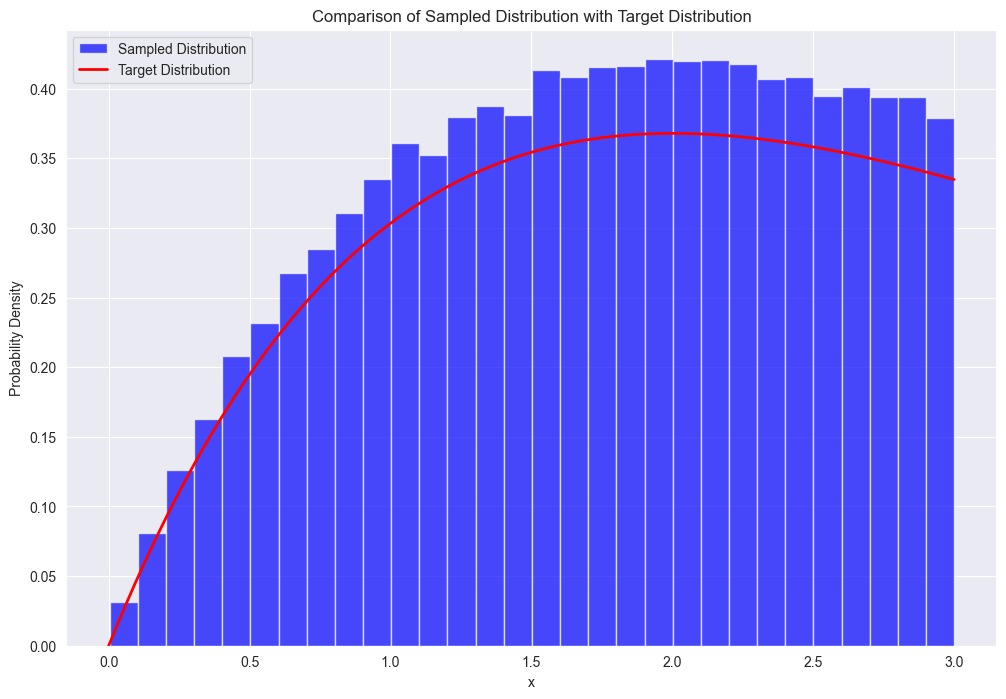

In [6]:
# Plot histogram of samples vs target distribution
plt.figure(figsize=(12, 8))

# Plot histogram of samples
plt.hist(samples, bins=30, density=True, alpha=0.7, color='blue', label='Sampled Distribution')

# Plot the original target distribution
plt.plot(x_values, y_values, 'r-', linewidth=2, label='Target Distribution')

plt.title('Comparison of Sampled Distribution with Target Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## 7. Using Different Proposal Distributions

The efficiency of acceptance-rejection sampling depends on how well the proposal distribution matches the target distribution. Let's try with a different proposal distribution to see the difference in efficiency.

New scaling factor for exponential proposal: 3.0000


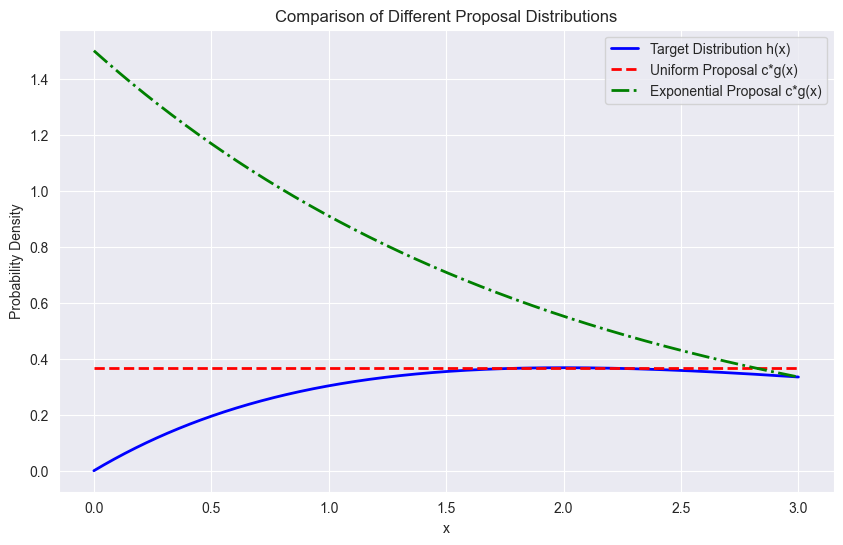

In [7]:
# Define a different proposal distribution (exponential)
def exp_proposal_pdf(x):
    """Exponential proposal distribution"""
    if x >= 0:
        return math.exp(-x/2) / 2  # Exponential with lambda=0.5
    else:
        return 0

# Calculate new scaling factor
ratios = [target_pdf(x) / exp_proposal_pdf(x) for x in x_values if exp_proposal_pdf(x) > 0]
c_exp = max(ratios)
print(f"New scaling factor for exponential proposal: {c_exp:.4f}")

# Plot both distributions
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution h(x)')
plt.plot(x_values, [c * proposal_pdf(x) for x in x_values], 'r--', linewidth=2, label=f'Uniform Proposal c*g(x)')
plt.plot(x_values, [c_exp * exp_proposal_pdf(x) for x in x_values], 'g-.', linewidth=2, label=f'Exponential Proposal c*g(x)')
plt.title('Comparison of Different Proposal Distributions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Implement acceptance-rejection with exponential proposal
def acceptance_rejection_sampling_exp(num_samples):
    """Generate samples using exponential proposal distribution"""
    samples = []
    total_attempts = 0
    
    while len(samples) < num_samples:
        total_attempts += 1
        
        # Sample from exponential distribution
        x_star = random.expovariate(0.5)  # lambda = 0.5
        
        # Only consider points within our range
        if x_star > 3:
            continue
            
        # Sample y from uniform distribution
        y = random.uniform(0, c_exp * exp_proposal_pdf(x_star))
        
        # Accept or reject
        if y <= target_pdf(x_star):
            samples.append(x_star)
    
    return samples, total_attempts

# Generate samples with exponential proposal
num_samples = 1000
samples_exp, total_attempts_exp = acceptance_rejection_sampling_exp(num_samples)

print(f"Generated {len(samples_exp)} samples using exponential proposal")
print(f"Total attempts: {total_attempts_exp}")
print(f"Acceptance rate: {len(samples_exp) / total_attempts_exp:.2%}")

# Compare with uniform proposal
_, _, total_points_uniform = acceptance_rejection_sampling(num_samples)
print(f"\nUniform proposal acceptance rate: {num_samples / len(total_points_uniform):.2%}")

Generated 1000 samples using exponential proposal
Total attempts: 3395
Acceptance rate: 29.46%

Uniform proposal acceptance rate: 418.41%


## 8. Conclusion

In this notebook, we've implemented the Acceptance-Rejection Sampling algorithm and demonstrated how it works. Key takeaways:

1. The algorithm allows us to sample from complex distributions using simpler proposal distributions
2. The efficiency depends on how well the proposal distribution matches the target distribution
3. A better matching proposal distribution leads to higher acceptance rates
4. The scaling factor c ensures the proposal distribution envelopes the target distribution

This method is fundamental in computational statistics and forms the basis for more advanced sampling techniques like Markov Chain Monte Carlo (MCMC) methods.